# XGBoost

In [46]:
import pandas as pd
import numpy as np
import os, joblib
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    f1_score, roc_auc_score, RocCurveDisplay
)
import warnings; warnings.filterwarnings('ignore')

BASE_DIR   = os.path.dirname(os.getcwd())
DATA_PATH  = os.path.join(BASE_DIR, 'data', 'processed_data.csv')
MODEL_DIR  = os.path.join(BASE_DIR, 'model')
os.makedirs(MODEL_DIR, exist_ok=True)


## 1. read

In [47]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'数据形状: {df.shape}  预订率: {df["booked"].mean():.2%}')

FEATURES = [c for c in df.columns if c not in ['booked', 'listing_id']]
X = df[FEATURES]
y = df['booked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# XGBoost 原生支持 NaN（enable_categorical 处理整数分类列）
CAT_FEATURES = ['host_response_time', 'neighbourhood_cleansed',
                'neighbourhood_group_cleansed', 'property_type', 'room_type']
for c in CAT_FEATURES:
    if c in X_train.columns:
        X_train[c] = X_train[c].astype('category')
        X_test[c]  = X_test[c].astype('category')

# 计算负样本/正样本比例，用于处理类别不平衡
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f'训练集: {X_train.shape}  测试集: {X_test.shape}')
print(f'scale_pos_weight = {spw:.2f}')

数据形状: (953380, 15)  预订率: 17.00%
训练集: (762704, 13)  测试集: (190676, 13)
scale_pos_weight = 4.88


## 2. train

In [48]:
model = xgb.XGBClassifier(
    n_estimators          = 500,
    learning_rate         = 0.05,
    max_depth             = 6,
    min_child_weight      = 50,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    scale_pos_weight      = spw,        # 处理类别不平衡
    enable_categorical    = True,       # 支持 category dtype
    device                = 'cuda',     
    eval_metric           = 'auc',
    early_stopping_rounds = 50,
    random_state          = 42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)
print(f'最优迭代轮数: {model.best_iteration}')

[0]	validation_0-auc:0.70363
[100]	validation_0-auc:0.85981
[200]	validation_0-auc:0.90181
[300]	validation_0-auc:0.92541
[400]	validation_0-auc:0.94072
[499]	validation_0-auc:0.95046
最优迭代轮数: 499


## 3. evaluate

In [49]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_prob)
f1  = f1_score(y_test, y_pred)
print(f'AUC-ROC : {auc:.4f}')
print(f'F1 Score: {f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['not booked','booked']))

AUC-ROC : 0.9505
F1 Score: 0.7054

Classification Report:
              precision    recall  f1-score   support

  not booked       0.97      0.88      0.92    158262
      booked       0.59      0.88      0.71     32414

    accuracy                           0.88    190676
   macro avg       0.78      0.88      0.81    190676
weighted avg       0.91      0.88      0.88    190676



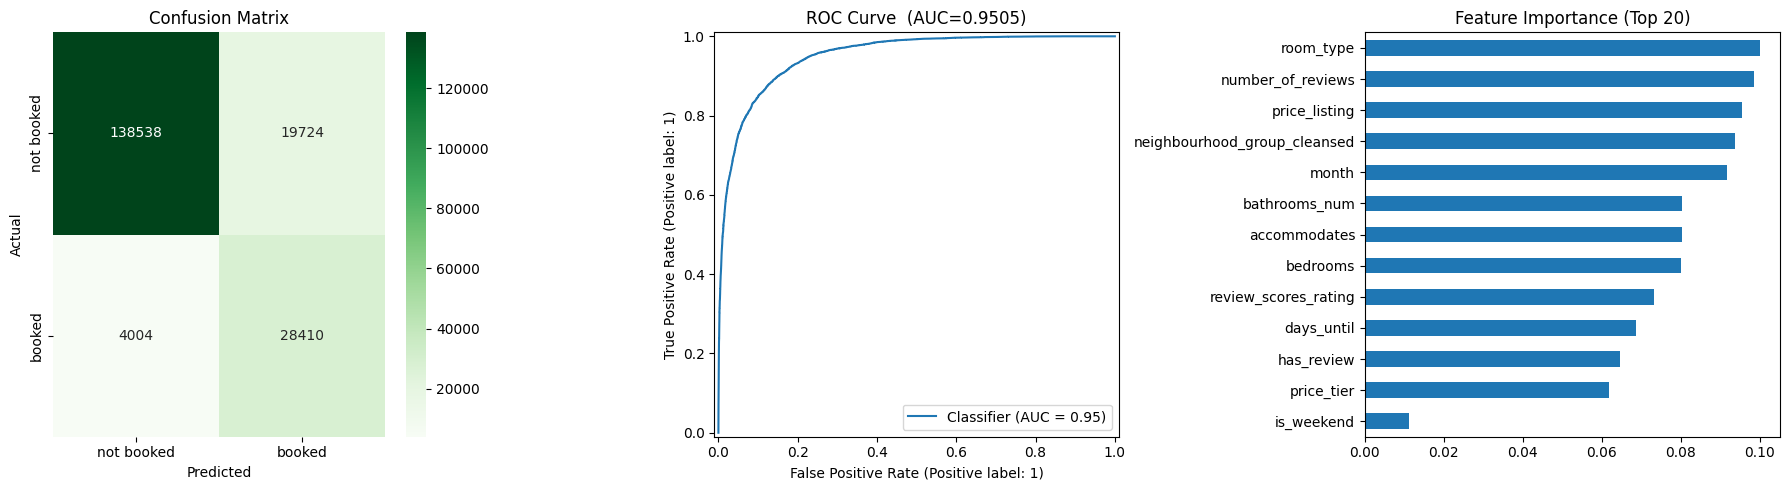

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['not booked','booked'],
            yticklabels=['not booked','booked'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC 曲线
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title(f'ROC Curve  (AUC={auc:.4f})')

# 特征重要性 Top20
imp = pd.Series(
    model.feature_importances_, index=FEATURES
).nlargest(20)
imp.sort_values().plot(kind='barh', ax=axes[2])
axes[2].set_title('Feature Importance (Top 20)')

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'xgboost_eval.png'), dpi=120)
plt.show()

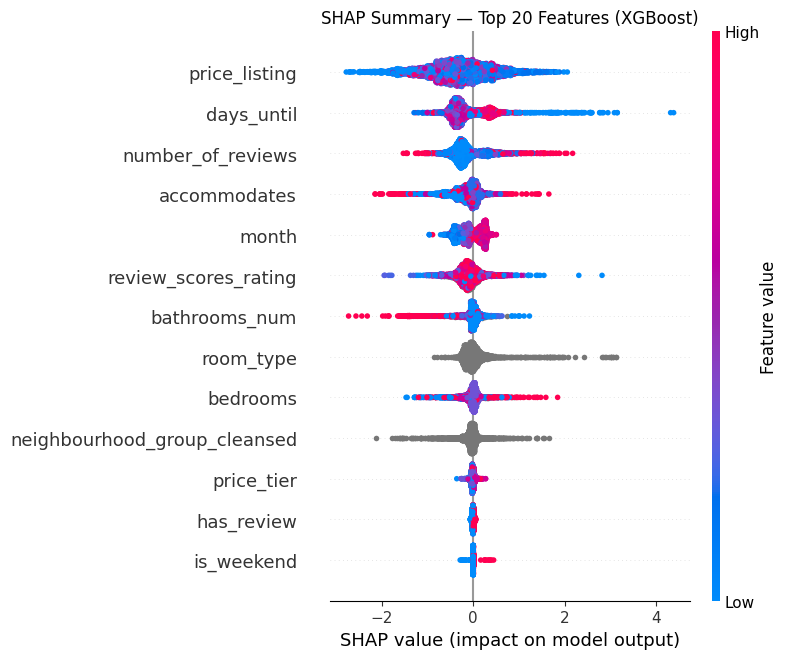

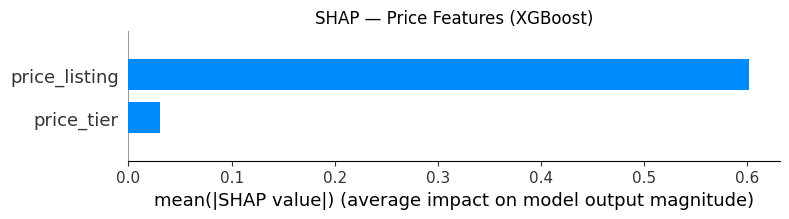

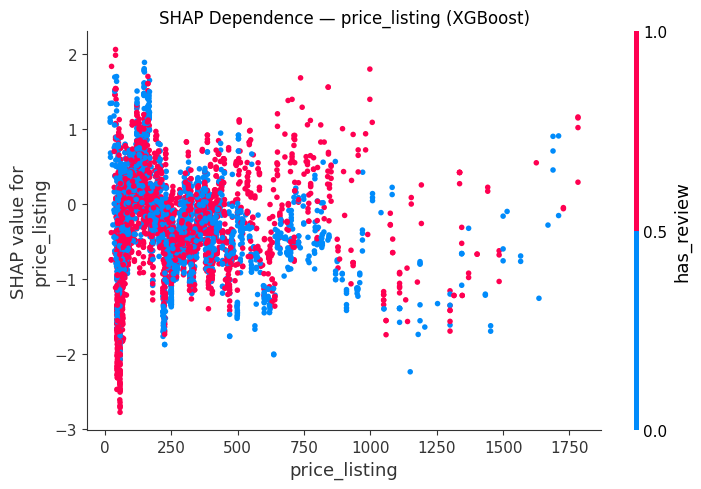

In [51]:
# ── Price 相关特征的全局 SHAP 分析 ────────────────────────────
import shap

sample_idx = X_test.sample(5000, random_state=42).index
X_shap = X_test.loc[sample_idx][FEATURES].copy()
for c in CAT_FEATURES:
    if c in X_shap.columns:
        X_shap[c] = X_shap[c].astype('category')

explainer   = shap.TreeExplainer(model)
# XGBoost + enable_categorical 与 shap 的 additivity check 不兼容，关闭即可
shap_values = explainer.shap_values(X_shap, check_additivity=False)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

# ── 1. 全局 Beeswarm ─────────────────────────────────────────
shap.summary_plot(sv, X_shap, max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Features (XGBoost)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'xgboost_shap_summary.png'), dpi=120)
plt.show()

# ── 2. Price 相关列 bar chart ─────────────────────────────────
price_cols = [c for c in FEATURES if 'price' in c or 'revenue' in c]
price_idx  = [FEATURES.index(c) for c in price_cols]

shap.summary_plot(sv[:, price_idx], X_shap[price_cols],
                  plot_type='bar', show=False)
plt.title('SHAP — Price Features (XGBoost)')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'xgboost_shap_price_bar.png'), dpi=120)
plt.show()

# ── 3. price_listing dependence plot ─────────────────────────
if 'price_listing' in FEATURES:
    shap.dependence_plot('price_listing', sv, X_shap, show=False)
    plt.title('SHAP Dependence — price_listing (XGBoost)')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, 'xgboost_shap_price_dep.png'), dpi=120)
    plt.show()

## 5. prediction example

In [52]:
# 从测试集随机取 5 条，展示模型输出的预订概率
# 注意：XGBoost 需要保持 category dtype
sample = X_test.sample(5, random_state=0).copy()
sample['actual_booked']    = y_test.loc[sample.index].values
sample['pred_probability'] = model.predict_proba(sample[FEATURES])[:, 1].round(4)

show_cols = ['days_until', 'day_of_week', 'is_weekend', 'month',
             'room_type', 'neighbourhood_group_cleansed',
             'price_listing', 'review_scores_rating',
             'actual_booked', 'pred_probability']
show_cols = [c for c in show_cols if c in sample.columns]
print('=== 预订概率示例（从测试集随机抽取）===')
sample[show_cols].reset_index(drop=True)

=== 预订概率示例（从测试集随机抽取）===


,days_until,is_weekend,month,room_type,neighbourhood_group_cleansed,price_listing,review_scores_rating,actual_booked,pred_probability
0,243,0,5,0,0,935.0,5.00,0,0.0565
1,291,0,7,0,0,276.0,NaN,0,0.3215
2,330,0,8,2,0,88.0,4.25,0,0.2308
3,326,0,8,2,0,205.0,5.00,0,0.4691
4,363,1,9,2,0,154.0,NaN,0,0.7357


## 4. save

In [53]:
# 保存模型（joblib pkl，含 feature list 和分类特征名）
model_path = os.path.join(MODEL_DIR, 'xgboost_model.pkl')
joblib.dump({'model': model, 'features': FEATURES, 'cat_features': CAT_FEATURES}, model_path)
print(f'模型已保存: {model_path}')

模型已保存: d:\School\msba\作业\5113\group\sg\model\xgboost_model.pkl


In [54]:
# ── 推理示例：load pkl → 输出预订概率 ────────────────────────
saved = joblib.load(os.path.join(MODEL_DIR, 'xgboost_model.pkl'))
loaded_model    = saved['model']
loaded_features = saved['features']
loaded_cats     = saved['cat_features']

# 取测试集中 3 条作为"新数据"模拟推理（需还原 category dtype）
new_data = X_test.iloc[:3][loaded_features].copy()
for c in loaded_cats:
    if c in new_data.columns:
        new_data[c] = new_data[c].astype('category')

probs = loaded_model.predict_proba(new_data)[:, 1]

result = new_data[['days_until', 'is_weekend', 'room_type', 
                   'price_listing']].copy()
result['pred_prob_booked'] = probs.round(4)
print('=== 推理示例（load pkl）===')
result.reset_index(drop=True)

=== 推理示例（load pkl）===


,days_until,is_weekend,room_type,price_listing,pred_prob_booked
0,83,1,2,69.0,0.0911
1,151,0,0,910.0,0.0280
2,250,0,2,170.0,0.1185


In [56]:
# ── 手动构造输入 → 输出预订概率 ──────────────────────────────
# label encoding 对应关系见 data/label_encoding_map.csv
row = pd.DataFrame([{
    'days_until'                  : 30,
    'day_of_week'                 : 5,
    'is_weekend'                  : 1,
    'month'                       : 7,
    'quarter'                     : 3,
    'day_of_year'                 : 200,
    'room_type'                   : 1,      # label encoded
    'neighbourhood_group_cleansed': 2,      # label encoded
    'neighbourhood_cleansed'      : 10,     # label encoded
    'property_type'               : 3,      # label encoded
    'price_listing'               : 100.0,
    'accommodates'                : 2,
    'bedrooms'                    : 1,
    'beds'                        : 1,
    'bathrooms_num'               : 1.0,
    'review_scores_rating'        : 4.8,
    'number_of_reviews'           : 50,
    'has_review'                  : 1,
    # 其余列留 NaN，XGBoost 原生处理缺失值
}])

row = row.reindex(columns=loaded_features)
# XGBoost 需要还原分类列的 category dtype
for c in loaded_cats:
    if c in row.columns:
        row[c] = row[c].astype('category')

prob = loaded_model.predict_proba(row)[0, 1]
print(f'预订概率: {prob:.4f}')

预订概率: 0.7669
